In [2]:
using Revise
using SSMCMain, SSMCMain.ModifiedMiCRM, SSMCMain.ModifiedMiCRM.MinimalModelV2, SSMCMain.ModifiedMiCRM.TwoMMs

In [3]:
using JLD2

In [4]:
includet("../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# Plotting outcomes with K

In [24]:
f = jldopen("../../cluster_env/runs/twomms1/wrtk_1/d1_k0.0.jld2")
fmetadata = f["metadata"]

Ks = f["Ks"]
numKs = length(Ks)
results = f["results"];

In [31]:
u1 = @view results[end-5].fss[1][1,:];

In [ ]:
mean(u1)

7.260920668264872

In [37]:
surv_threshold = 1e-9
num_ext = zeros(numKs)
num_coex = zeros(numKs)
num_S1 = zeros(numKs)
num_S2 = zeros(numKs)
num_bad = zeros(numKs)
for iK in 1:length(Ks)
    for (rc, fT, fs) in zip(results[iK].retcodes, results[iK].fTs, results[iK].fss)
        if (fT == fmetadata.T) && (rc == ReturnCode.Success)
            m1 = mean(@view fs[1,:])
            m2 = mean(@view fs[2,:])
            if (m1 < surv_threshold) && (m2 < surv_threshold)
                num_ext[iK] += 1
            elseif (m1 < surv_threshold)
                num_S2[iK] += 1
            elseif (m2 < surv_threshold)
                num_S1[iK] += 1
            else
                num_coex[iK] += 1
            end
        else
            num_bad[iK] += 1
        end
    end
end
@assert all((num_ext .+ num_coex .+ num_S1 .+ num_S2 .+ num_bad) .== num_repeats)

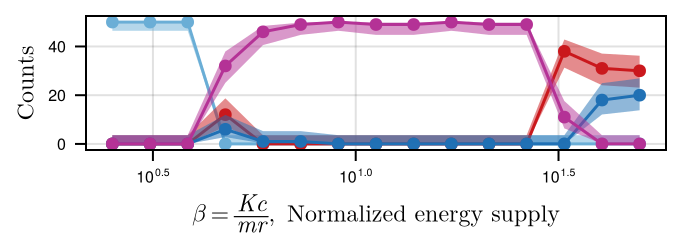

In [39]:
fig = Figure(;
    # size=(double_col_width * 0.45, (double_col_width / golden_ratio) * 0.52),
    figure_padding=(8., 8., 8., 8.),
    size=(double_col_width * 0.5, (double_col_width / golden_ratio) * 0.3),
)
ax = Axis(fig[1,1];
    xscale=log10,
    xlabel=L"\beta=\frac{Kc}{mr},\enspace\text{Normalized energy supply}",
    ylabel=L"\text{Counts}",
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
)

plot_binom_sample!(ax, Ks, num_ext, num_repeats;
    color=PaperColors.extinct1(),
    label="Extinction",
)
plot_binom_sample!(ax, Ks, num_S1, num_repeats;
    color=PaperColors.twomms_1(),
    label="Extinction",
)
plot_binom_sample!(ax, Ks, num_S2, num_repeats;
    color=PaperColors.twomms_2(),
    label="Extinction",
)
plot_binom_sample!(ax, Ks, num_coex, num_repeats;
    color=PaperColors.twomms_coexistence(),
    label="Extinction",
)

# vlines!(ax, [Ks[4], Ks[11]];
    # color=:black,
    # linestyle=:dash,
# )

Makie.save("../../figures/fig4_cmms/poster_props.pdf", fig)

fig

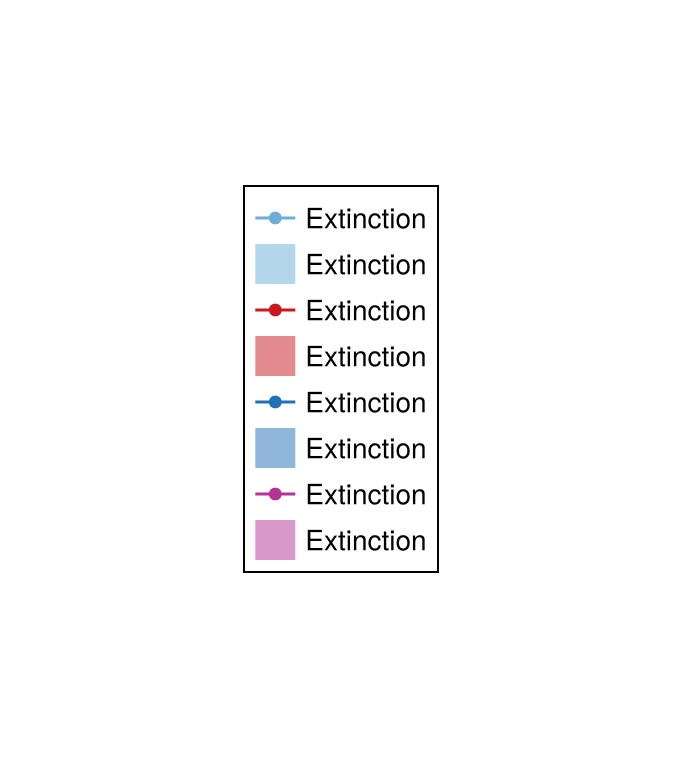

In [56]:
fig = Figure(;
    # size=(double_col_width * 0.45, (double_col_width / golden_ratio) * 0.52),
    figure_padding=(8., 8., 8., 8.),
    size=(double_col_width * 0.5, (double_col_width / golden_ratio) * 0.9),
)
Legend(fig[1,1], ax)
Makie.save("../../figures/fig4_cmms/legend_base.pdf", fig)
fig